In [ ]:
# Core libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Models
from sklearn.ensemble import RandomForestRegressor

# Metrics (Regression)
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [ ]:
from google.colab import files
files.upload()

Saving Diamond_Price.csv to Diamond_Price.csv


{'Diamond_Price.csv': b'"","X","Carat","Color","Clarity","Depth","PricePerCt","TotalPrice"\r\n"1",1,1.08,"E","VS1",68.6,6693.3,7228.8\r\n"2",2,0.31,"F","VVS1",61.9,3159,979.3\r\n"3",3,0.32,"F","VVS1",60.8,3159,1010.9\r\n"4",4,0.33,"D","IF",60.8,4758.8,1570.4\r\n"5",5,0.33,"G","VVS1",61.5,2895.8,955.6\r\n"6",6,0.35,"F","VS1",62.5,2457,860\r\n"7",7,0.35,"F","VS1",62.3,2457,860\r\n"8",8,0.37,"F","VVS1",61.4,3402,1258.7\r\n"9",9,0.38,"D","IF",60,5062.5,1923.8\r\n"10",10,0.38,"E","VVS2",61.5,3496.5,1328.7\r\n"11",11,0.38,"F","IF",61.8,4252.5,1616\r\n"12",12,0.39,"D","VVS1",61.7,4158,1621.6\r\n"13",13,0.39,"D","VS1",61.7,2983.5,1163.6\r\n"14",14,0.39,"F","IF",61.3,3969,1547.9\r\n"15",15,0.39,"F","VVS1",61.1,3422.3,1334.7\r\n"16",16,0.4,"D","VVS2",59.7,3422.3,1368.9\r\n"17",17,0.4,"D","VVS2",59.6,3422.3,1368.9\r\n"18",18,0.4,"E","VS1",62.2,2937.6,1175\r\n"19",19,0.4,"F","VVS2",60.8,2983.5,1193.4\r\n"20",20,0.4,"F","VVS2",61.7,3121.2,1248.5\r\n"21",21,0.4,"G","VVS1",61.7,3213,1285.2\r\n"22",22

In [ ]:
import pandas as pd

df = pd.read_csv("Diamond_Price.csv")
df.head()

,Unnamed: 0,X,Carat,Color,Clarity,Depth,PricePerCt,TotalPrice
0,1,1,1.08,E,VS1,68.6,6693.3,7228.8
1,2,2,0.31,F,VVS1,61.9,3159.0,979.3
2,3,3,0.32,F,VVS1,60.8,3159.0,1010.9
3,4,4,0.33,D,IF,60.8,4758.8,1570.4
4,5,5,0.33,G,VVS1,61.5,2895.8,955.6


In [ ]:
df.columns

Index(['Unnamed: 0', 'X', 'Carat', 'Color', 'Clarity', 'Depth', 'PricePerCt',
       'TotalPrice'],
      dtype='object')

In [ ]:
df.drop(columns=['Unnamed: 0', 'X'], inplace=True)

In [ ]:
df.head()

,Carat,Color,Clarity,Depth,PricePerCt,TotalPrice
0,1.08,E,VS1,68.6,6693.3,7228.8
1,0.31,F,VVS1,61.9,3159.0,979.3
2,0.32,F,VVS1,60.8,3159.0,1010.9
3,0.33,D,IF,60.8,4758.8,1570.4
4,0.33,G,VVS1,61.5,2895.8,955.6


In [ ]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307 entries, 0 to 306
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Carat       307 non-null    float64
 1   Color       307 non-null    object 
 2   Clarity     307 non-null    object 
 3   Depth       307 non-null    float64
 4   PricePerCt  307 non-null    float64
 5   TotalPrice  307 non-null    float64
dtypes: float64(4), object(2)
memory usage: 14.5+ KB


,Carat,Depth,PricePerCt,TotalPrice
count,307.000000,307.000000,307.000000,307.000000
mean,0.973094,64.446580,6292.845277,7381.345928
std,0.493946,5.174909,2969.074593,8000.251838
min,0.310000,58.200000,1782.000000,853.300000
25%,0.630000,61.200000,4212.000000,2759.850000
50%,0.820000,62.000000,5197.500000,4243.800000
75%,1.220000,68.650000,7987.950000,9298.800000
max,3.350000,79.200000,17671.500000,56454.400000


In [ ]:
df.isnull().sum()

,0
Carat,0
Color,0
Clarity,0
Depth,0
PricePerCt,0
TotalPrice,0


In [ ]:
# Display all column names
print("All Columns in Dataset:")
print(df.columns.tolist())

# Identify numeric columns (exclude target later if needed)
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("\nNumeric Columns:")
print(numeric_cols)

# Identify categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print("\nCategorical Columns:")
print(categorical_cols)


All Columns in Dataset:
['Carat', 'Color', 'Clarity', 'Depth', 'PricePerCt', 'TotalPrice']

Numeric Columns:
['Carat', 'Depth', 'PricePerCt', 'TotalPrice']

Categorical Columns:
['Color', 'Clarity']


In [ ]:
# 🧾 Step 4: Use .info() to check:
# - Data types (int, float, object)
# - How many non-null entries each column has
# This helps identify missing values and memory usage
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307 entries, 0 to 306
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Carat       307 non-null    float64
 1   Color       307 non-null    object 
 2   Clarity     307 non-null    object 
 3   Depth       307 non-null    float64
 4   PricePerCt  307 non-null    float64
 5   TotalPrice  307 non-null    float64
dtypes: float64(4), object(2)
memory usage: 14.5+ KB


In [ ]:
# 🔍 Step 5: Randomly sample 5 rows from the dataset
# This helps us get an unbiased feel for the data
df.sample(5)

,Carat,Color,Clarity,Depth,PricePerCt,TotalPrice
262,1.20,F,VS1,72.6,7188.8,8626.5
18,0.40,F,VVS2,60.8,2983.5,1193.4
165,1.07,G,VS2,62.3,7095.6,7592.3
235,0.72,E,VS2,74.7,4268.7,3073.5
90,0.71,E,VS1,62.5,4738.5,3364.3


In [ ]:
# 🔁 Step 8: Check if any rows in the dataset are duplicates
# Duplicate data can lead to bias in analysis and model training
df.duplicated().sum()


np.int64(0)

In [ ]:
# 🔢 Step 9: See how many unique values each column contains
# Helps identify categorical vs numeric features and high-cardinality columns
df.nunique()

,0
Carat,112
Color,4
Clarity,8
Depth,97
PricePerCt,203
TotalPrice,292


In [ ]:
# Target column
target_col = "TotalPrice"

# Numeric feature columns ONLY (exclude target)
numeric_columns = ["Carat", "Depth", "PricePerCt"]


In [ ]:
# ------------------------------------------------------------
# Outlier Detection in Diamond Dataset using IQR Method
# ------------------------------------------------------------

import pandas as pd

# ✅ Step 1: Select relevant numeric columns (exclude index-like column 'X')
numeric_columns = ['Carat', 'Depth', 'PricePerCt', 'TotalPrice']

# ✅ Step 2: Collect indices of outliers using IQR rule
outlier_indices = set()

for col in numeric_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Find outliers for this column
    col_outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)].index
    outlier_indices.update(col_outliers)

    print(
        f"📊 {col} | "
        f"Lower={lower_bound:.2f}, Upper={upper_bound:.2f}, "
        f"Outliers={len(col_outliers)}"
    )

# ✅ Step 3: View outlier rows (optional)
print("\n🔍 Outlier Rows Detected (IQR Method):")
if outlier_indices:
    display(df.loc[list(outlier_indices)])
else:
    print("✅ No outliers detected based on the IQR method.")


📊 Carat | Lower=-0.26, Upper=2.10, Outliers=9
📊 Depth | Lower=50.02, Upper=79.83, Outliers=0
📊 PricePerCt | Lower=-1451.92, Upper=13651.88, Outliers=10
📊 TotalPrice | Lower=-7048.57, Upper=19107.22, Outliers=19

🔍 Outlier Rows Detected (IQR Method):


,Carat,Color,Clarity,Depth,PricePerCt,TotalPrice
291,2.01,G,VS1,72.1,10189.8,20481.5
292,2.03,F,VS2,72.9,11340.0,23020.2
293,2.03,F,VS2,74.2,11037.6,22406.3
294,2.03,G,VS2,71.3,10428.8,21170.4
295,2.06,F,VVS1,70.5,14175.0,29200.5
296,2.33,G,VS2,74.2,10428.8,24299.0
297,2.53,G,IF,74.3,12757.5,32276.5
298,3.01,F,VVS1,71.5,17671.5,53191.2
299,3.01,G,VS1,72.0,14782.5,44495.3
300,3.17,F,VVS2,71.5,17313.8,54884.6


In [ ]:
outlier_df = df.loc[list(outlier_indices)]
outlier_count = outlier_df.shape[0]
print(f"Number of rows with potential feature outliers (IQR method): {outlier_count}")


Number of rows with potential feature outliers (IQR method): 20


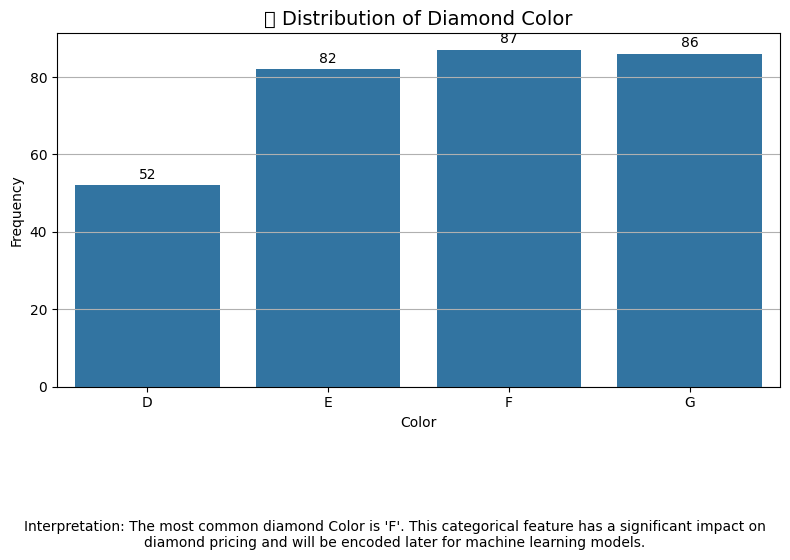

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# ================================
# Column to analyze (categorical)
# ================================
col = 'Color'   # change to 'Clarity' if needed

# ================================
# Count frequencies
# ================================
value_counts = df[col].value_counts().sort_index()

# ================================
# Plot bar chart
# ================================
plt.figure(figsize=(8, 5))
sns.barplot(x=value_counts.index, y=value_counts.values)

# ================================
# Add count labels on top of bars
# ================================
for i, val in enumerate(value_counts.values):
    plt.text(i, val + 1, str(val), ha='center', va='bottom', fontsize=10)

# ================================
# Labels and title
# ================================
plt.title(f"💎 Distribution of Diamond {col}", fontsize=14)
plt.xlabel(col)
plt.ylabel("Frequency")
plt.grid(axis='y')

# ================================
# Mode of the variable
# ================================
mode_val = df[col].mode()[0]

# ================================
# Teaching-style interpretation
# ================================
plt.figtext(
    0.5, -0.15,
    f"Interpretation: The most common diamond {col} is '{mode_val}'. "
    f"This categorical feature has a significant impact on diamond pricing "
    f"and will be encoded later for machine learning models.",
    wrap=True, ha='center', fontsize=10
)

# ================================
# Final display
# ================================
plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()



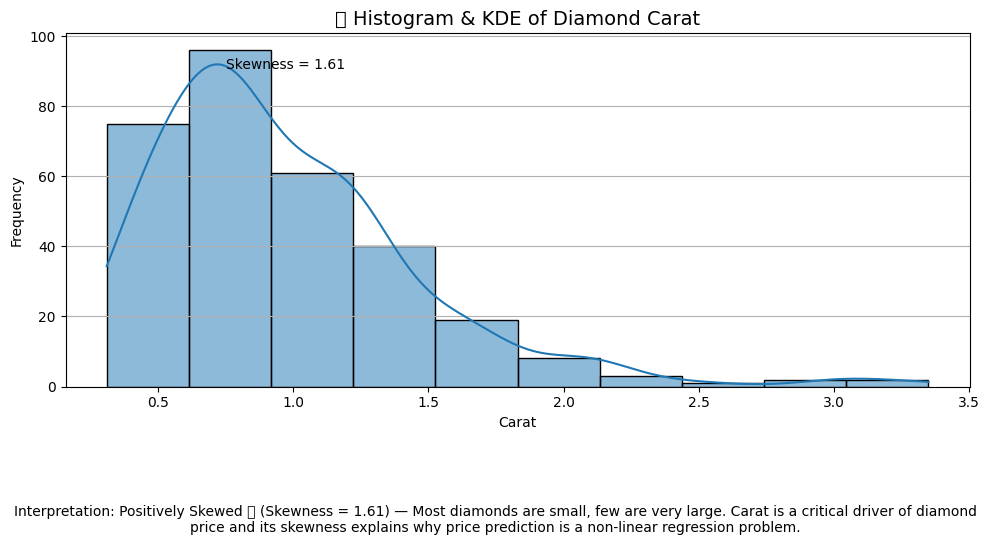

,Carat Range,Frequency
0,0.31 – 0.61,75
1,0.61 – 0.92,96
2,0.92 – 1.22,61
3,1.22 – 1.53,40
4,1.53 – 1.83,19
5,1.83 – 2.13,8
6,2.13 – 2.44,3
7,2.44 – 2.74,1
8,2.74 – 3.05,2
9,3.05 – 3.35,2


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ================================
# Column to analyze (numeric)
# ================================
col = 'Carat'

# ================================
# Histogram + KDE plot
# ================================
plt.figure(figsize=(10, 5))
sns.histplot(df[col], bins=10, kde=True, edgecolor='black')

# ================================
# Titles and labels
# ================================
plt.title(f"💎 Histogram & KDE of Diamond {col}", fontsize=14)
plt.xlabel(col)
plt.ylabel("Frequency")
plt.grid(axis='y')

# ================================
# Skewness calculation
# ================================
skew = df[col].skew()
skew_val = round(skew, 2)

if skew > 0.5:
    skew_type = f"Positively Skewed 📈 (Skewness = {skew_val}) — Most diamonds are small, few are very large"
elif skew < -0.5:
    skew_type = f"Negatively Skewed 📉 (Skewness = {skew_val}) — Most diamonds are large, few are small"
else:
    skew_type = f"Approximately Symmetric ✅ (Skewness = {skew_val}) — Balanced carat distribution"

# ================================
# Display skewness on plot
# ================================
plt.text(
    x=df[col].mean(),
    y=plt.ylim()[1] * 0.9,
    s=f"Skewness = {skew_val}",
    fontsize=10,
    ha='center'
)

# ================================
# Teaching-style interpretation
# ================================
plt.figtext(
    0.5, -0.12,
    f"Interpretation: {skew_type}. "
    f"Carat is a critical driver of diamond price and its skewness explains "
    f"why price prediction is a non-linear regression problem.",
    wrap=True,
    ha='center',
    fontsize=10
)

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

# ================================
# Bin frequency table
# ================================
counts, bin_edges = np.histogram(df[col], bins=10)
bin_labels = [
    f"{round(bin_edges[i], 2)} – {round(bin_edges[i+1], 2)}"
    for i in range(len(counts))
]

carat_bins = pd.DataFrame({
    'Carat Range': bin_labels,
    'Frequency': counts.astype(int)
})

carat_bins


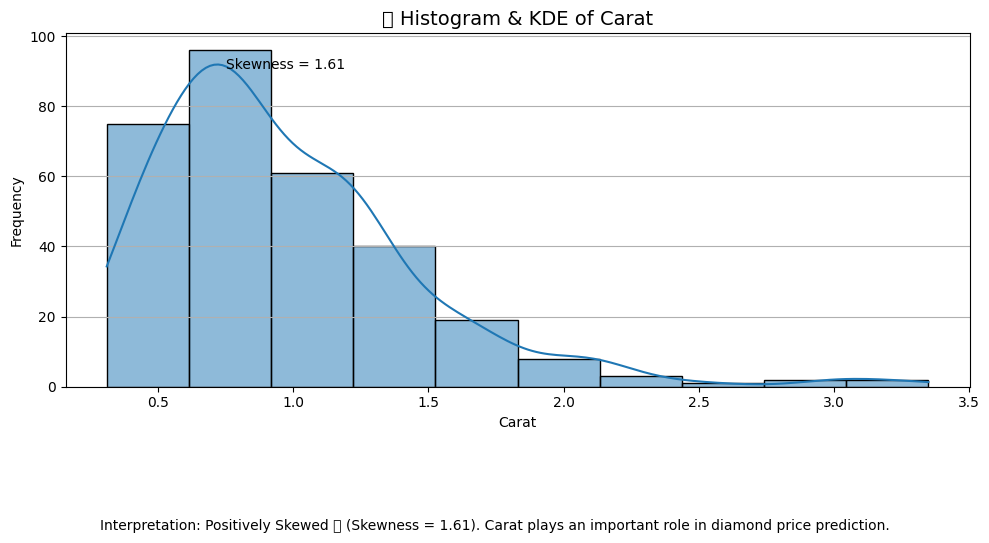

,Carat Range,Frequency
0,0.31 – 0.61,75
1,0.61 – 0.92,96
2,0.92 – 1.22,61
3,1.22 – 1.53,40
4,1.53 – 1.83,19
5,1.83 – 2.13,8
6,2.13 – 2.44,3
7,2.44 – 2.74,1
8,2.74 – 3.05,2
9,3.05 – 3.35,2


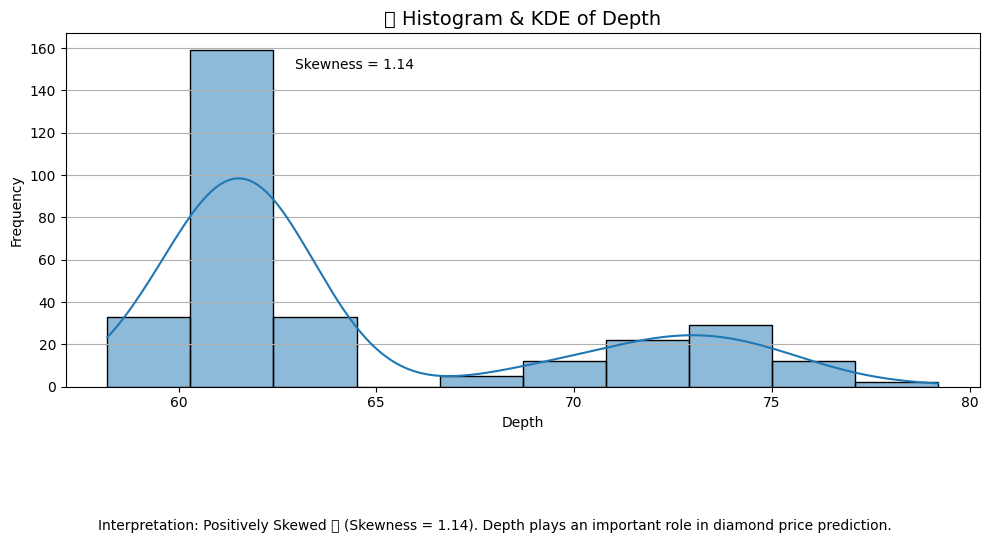

,Depth Range,Frequency
0,58.2 – 60.3,33
1,60.3 – 62.4,159
2,62.4 – 64.5,33
3,64.5 – 66.6,0
4,66.6 – 68.7,5
5,68.7 – 70.8,12
6,70.8 – 72.9,22
7,72.9 – 75.0,29
8,75.0 – 77.1,12
9,77.1 – 79.2,2


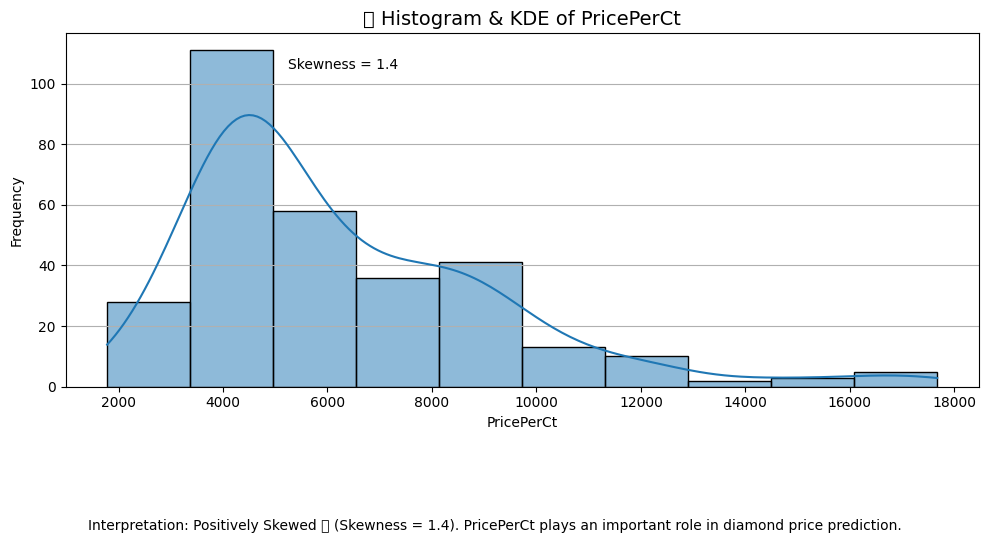

,PricePerCt Range,Frequency
0,1782.0 – 3370.95,28
1,3370.95 – 4959.9,111
2,4959.9 – 6548.85,58
3,6548.85 – 8137.8,36
4,8137.8 – 9726.75,41
5,9726.75 – 11315.7,13
6,11315.7 – 12904.65,10
7,12904.65 – 14493.6,2
8,14493.6 – 16082.55,3
9,16082.55 – 17671.5,5


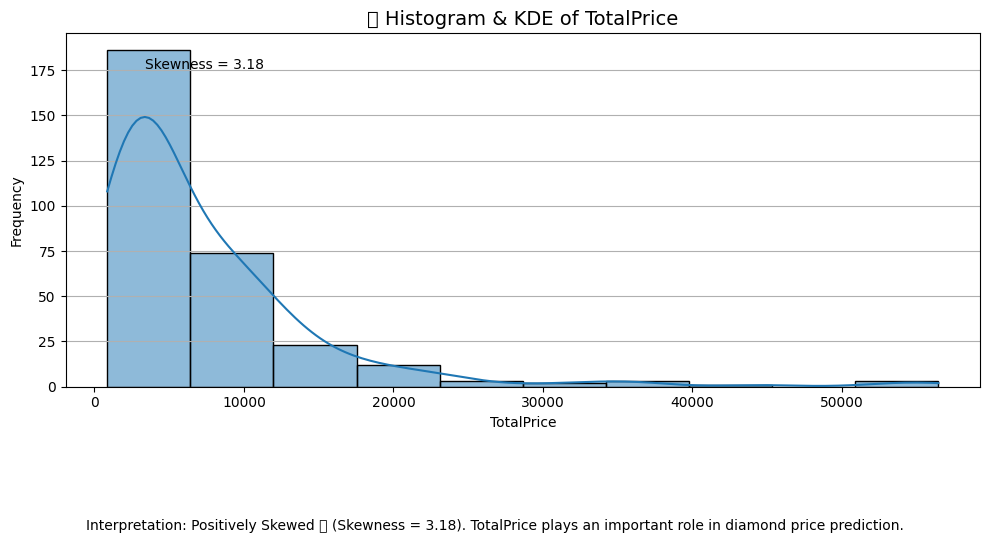

,TotalPrice Range,Frequency
0,853.3 – 6413.41,186
1,6413.41 – 11973.52,74
2,11973.52 – 17533.63,23
3,17533.63 – 23093.74,12
4,23093.74 – 28653.85,3
5,28653.85 – 34213.96,2
6,34213.96 – 39774.07,3
7,39774.07 – 45334.18,1
8,45334.18 – 50894.29,0
9,50894.29 – 56454.4,3


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

for col in numeric_columns:

    plt.figure(figsize=(10, 5))
    sns.histplot(df[col], bins=10, kde=True, edgecolor='black')

    plt.title(f"📊 Histogram & KDE of {col}", fontsize=14)
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.grid(axis='y')

    # Skewness
    skew = df[col].skew()
    skew_val = round(skew, 2)

    if skew > 0.5:
        skew_type = f"Positively Skewed 📈 (Skewness = {skew_val})"
    elif skew < -0.5:
        skew_type = f"Negatively Skewed 📉 (Skewness = {skew_val})"
    else:
        skew_type = f"Approximately Symmetric ✅ (Skewness = {skew_val})"

    plt.text(
        x=df[col].mean(),
        y=plt.ylim()[1] * 0.9,
        s=f"Skewness = {skew_val}",
        fontsize=10,
        ha='center'
    )

    plt.figtext(
        0.5, -0.12,
        f"Interpretation: {skew_type}. "
        f"{col} plays an important role in diamond price prediction.",
        wrap=True,
        ha='center',
        fontsize=10
    )

    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.show()

    # Bin frequency table
    counts, bin_edges = np.histogram(df[col], bins=10)
    bin_labels = [
        f"{round(bin_edges[i], 2)} – {round(bin_edges[i+1], 2)}"
        for i in range(len(counts))
    ]

    bin_df = pd.DataFrame({
        f"{col} Range": bin_labels,
        "Frequency": counts.astype(int)
    })

    display(bin_df)


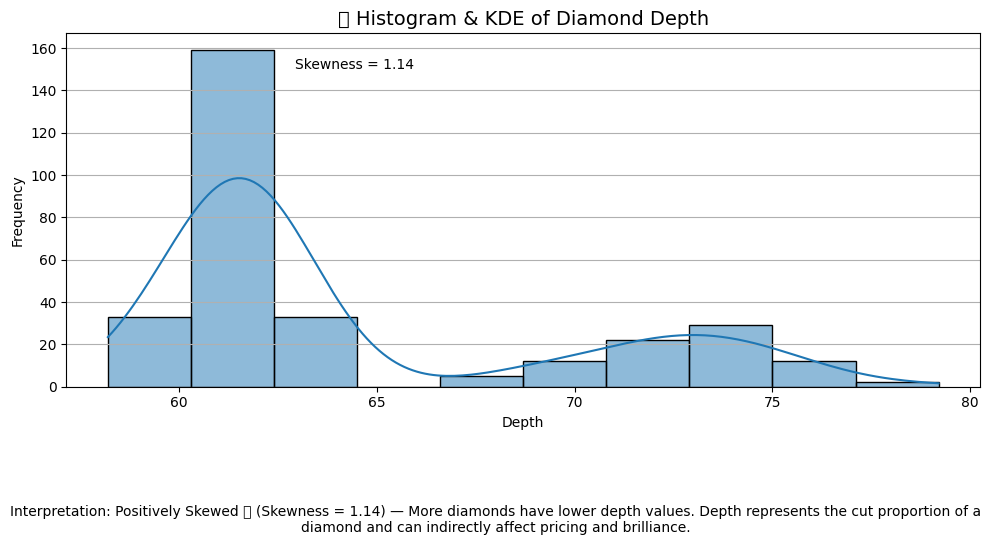

,Depth Range,Frequency
0,58.2 – 60.3,33
1,60.3 – 62.4,159
2,62.4 – 64.5,33
3,64.5 – 66.6,0
4,66.6 – 68.7,5
5,68.7 – 70.8,12
6,70.8 – 72.9,22
7,72.9 – 75.0,29
8,75.0 – 77.1,12
9,77.1 – 79.2,2


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ================================
# Column to analyze
# ================================
col = 'Depth'

# ================================
# Histogram + KDE
# ================================
plt.figure(figsize=(10, 5))
sns.histplot(df[col], bins=10, kde=True, edgecolor='black')

# ================================
# Titles and labels
# ================================
plt.title(f"📐 Histogram & KDE of Diamond {col}", fontsize=14)
plt.xlabel(col)
plt.ylabel("Frequency")
plt.grid(axis='y')

# ================================
# Skewness calculation
# ================================
skew = df[col].skew()
skew_val = round(skew, 2)

if skew > 0.5:
    skew_type = (
        f"Positively Skewed 📈 (Skewness = {skew_val}) — "
        f"More diamonds have lower depth values"
    )
elif skew < -0.5:
    skew_type = (
        f"Negatively Skewed 📉 (Skewness = {skew_val}) — "
        f"More diamonds have higher depth values"
    )
else:
    skew_type = (
        f"Approximately Symmetric ✅ (Skewness = {skew_val}) — "
        f"Depth values are well balanced"
    )

# ================================
# Skewness annotation on plot
# ================================
plt.text(
    x=df[col].mean(),
    y=plt.ylim()[1] * 0.9,
    s=f"Skewness = {skew_val}",
    fontsize=10,
    ha='center'
)

# ================================
# Teaching-style interpretation
# ================================
plt.figtext(
    0.5, -0.12,
    f"Interpretation: {skew_type}. "
    f"Depth represents the cut proportion of a diamond and can "
    f"indirectly affect pricing and brilliance.",
    wrap=True,
    ha='center',
    fontsize=10
)

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

# ================================
# Bin frequency table
# ================================
counts, bin_edges = np.histogram(df[col], bins=10)
bin_labels = [
    f"{round(bin_edges[i], 2)} – {round(bin_edges[i+1], 2)}"
    for i in range(len(counts))
]

depth_bins = pd.DataFrame({
    'Depth Range': bin_labels,
    'Frequency': counts.astype(int)
})

depth_bins


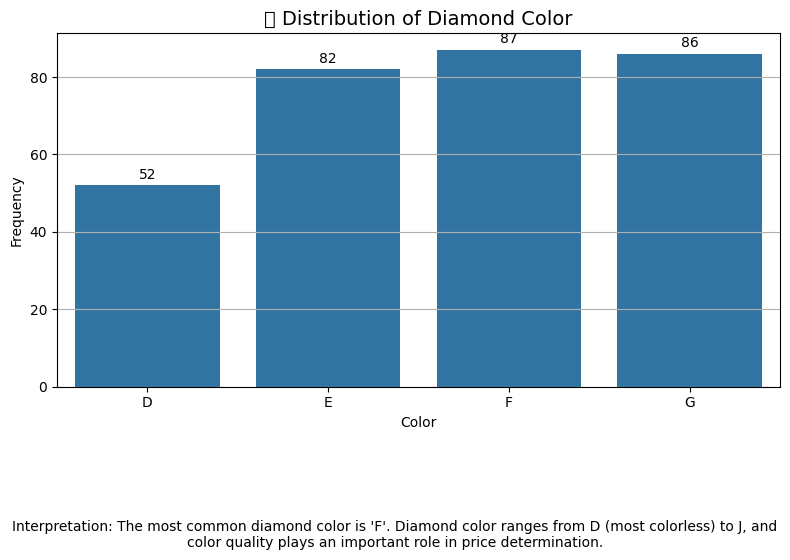

In [ ]:
#Categorical- Univariate
import matplotlib.pyplot as plt
import seaborn as sns

# ================================
# Column to analyze
# ================================
col = 'Color'

# ================================
# Frequency counts
# ================================
value_counts = df[col].value_counts().sort_index()

# ================================
# Bar plot
# ================================
plt.figure(figsize=(8, 5))
sns.barplot(x=value_counts.index, y=value_counts.values)

# ================================
# Add count labels on bars
# ================================
for i, val in enumerate(value_counts.values):
    plt.text(i, val + 1, str(val), ha='center', va='bottom', fontsize=10)

# ================================
# Titles and labels
# ================================
plt.title(f"🎨 Distribution of Diamond {col}", fontsize=14)
plt.xlabel(col)
plt.ylabel("Frequency")
plt.grid(axis='y')

# ================================
# Mode calculation
# ================================
mode_val = df[col].mode()[0]

# ================================
# Teaching-style interpretation
# ================================
plt.figtext(
    0.5, -0.15,
    f"Interpretation: The most common diamond color is '{mode_val}'. "
    f"Diamond color ranges from D (most colorless) to J, and color quality "
    f"plays an important role in price determination.",
    wrap=True,
    ha='center',
    fontsize=10
)

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()


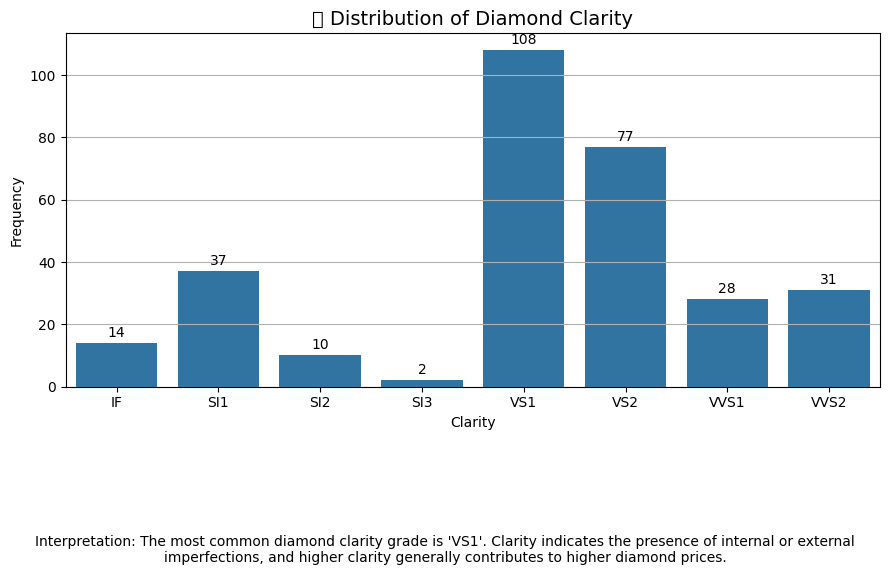

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# ================================
# Column to analyze
# ================================
col = 'Clarity'

# ================================
# Frequency counts
# ================================
value_counts = df[col].value_counts().sort_index()

# ================================
# Bar plot
# ================================
plt.figure(figsize=(9, 5))
sns.barplot(x=value_counts.index, y=value_counts.values)

# ================================
# Add count labels on bars
# ================================
for i, val in enumerate(value_counts.values):
    plt.text(i, val + 1, str(val), ha='center', va='bottom', fontsize=10)

# ================================
# Titles and labels
# ================================
plt.title(f"🔍 Distribution of Diamond {col}", fontsize=14)
plt.xlabel(col)
plt.ylabel("Frequency")
plt.grid(axis='y')

# ================================
# Mode calculation
# ================================
mode_val = df[col].mode()[0]

# ================================
# Teaching-style interpretation
# ================================
plt.figtext(
    0.5,
    -0.18,
    (
        f"Interpretation: The most common diamond clarity grade is '{mode_val}'. "
        f"Clarity indicates the presence of internal or external imperfections, "
        f"and higher clarity generally contributes to higher diamond prices."
    ),
    wrap=True,
    ha='center',
    fontsize=10
)

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()


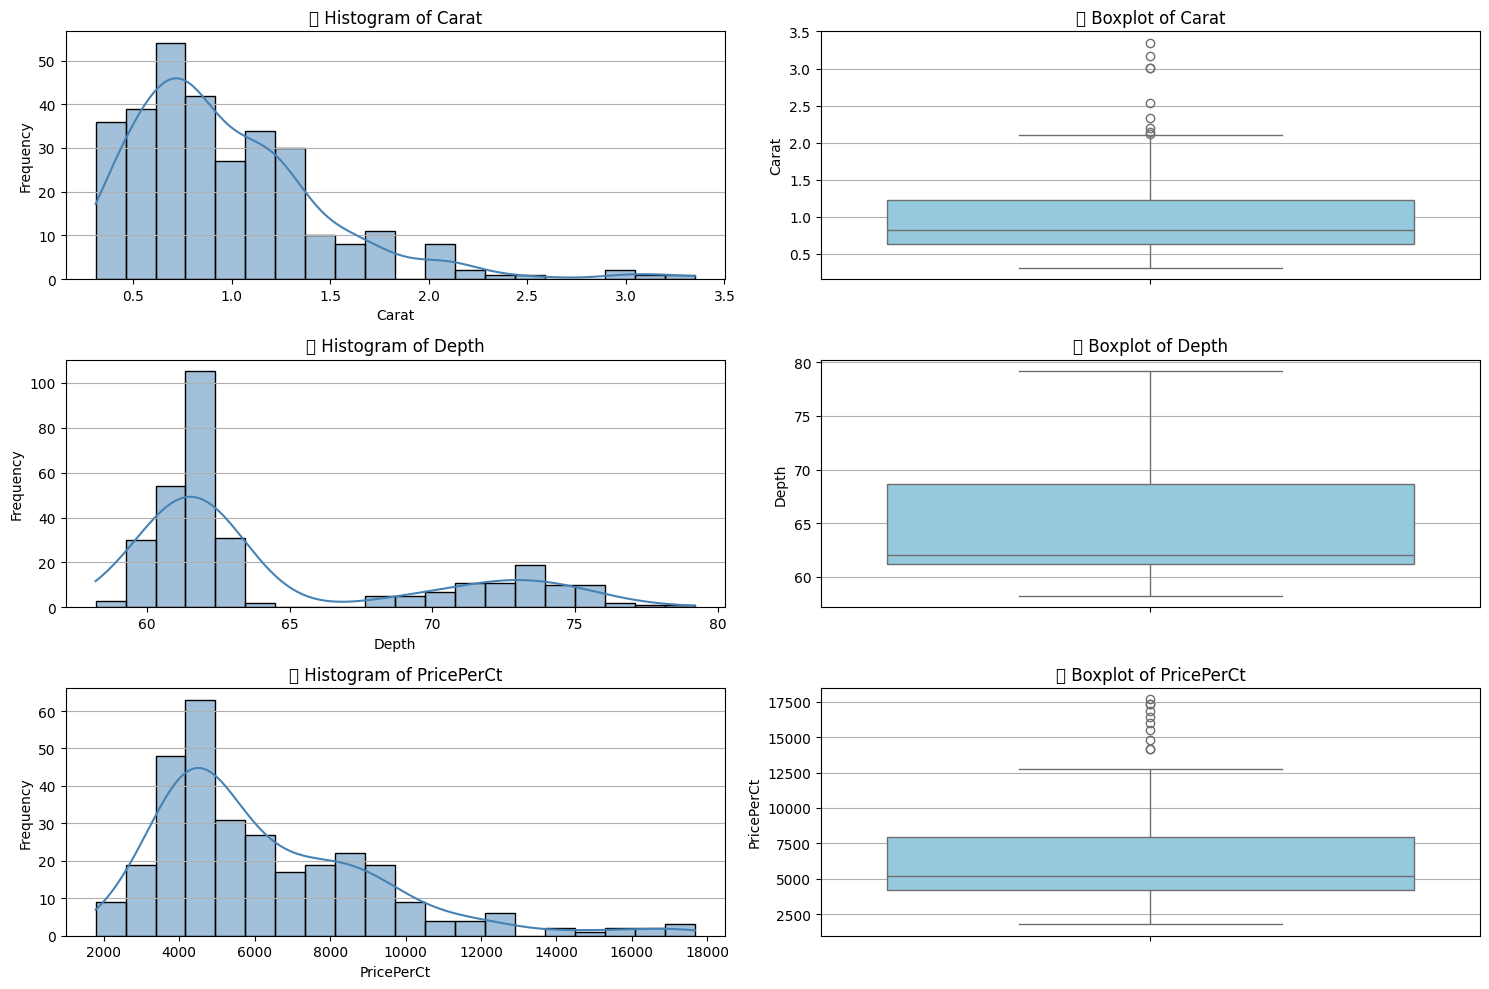

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_columns = ['Carat', 'Depth', 'PricePerCt']

plt.figure(figsize=(15, 10))

for i, col in enumerate(numeric_columns):

    # Histogram
    plt.subplot(len(numeric_columns), 2, 2*i + 1)
    sns.histplot(df[col], bins=20, kde=True, color='steelblue')
    plt.title(f"📊 Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.grid(axis='y')

    # Boxplot
    plt.subplot(len(numeric_columns), 2, 2*i + 2)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(f"📦 Boxplot of {col}")
    plt.ylabel(col)
    plt.grid(axis='y')

plt.tight_layout()
plt.show()


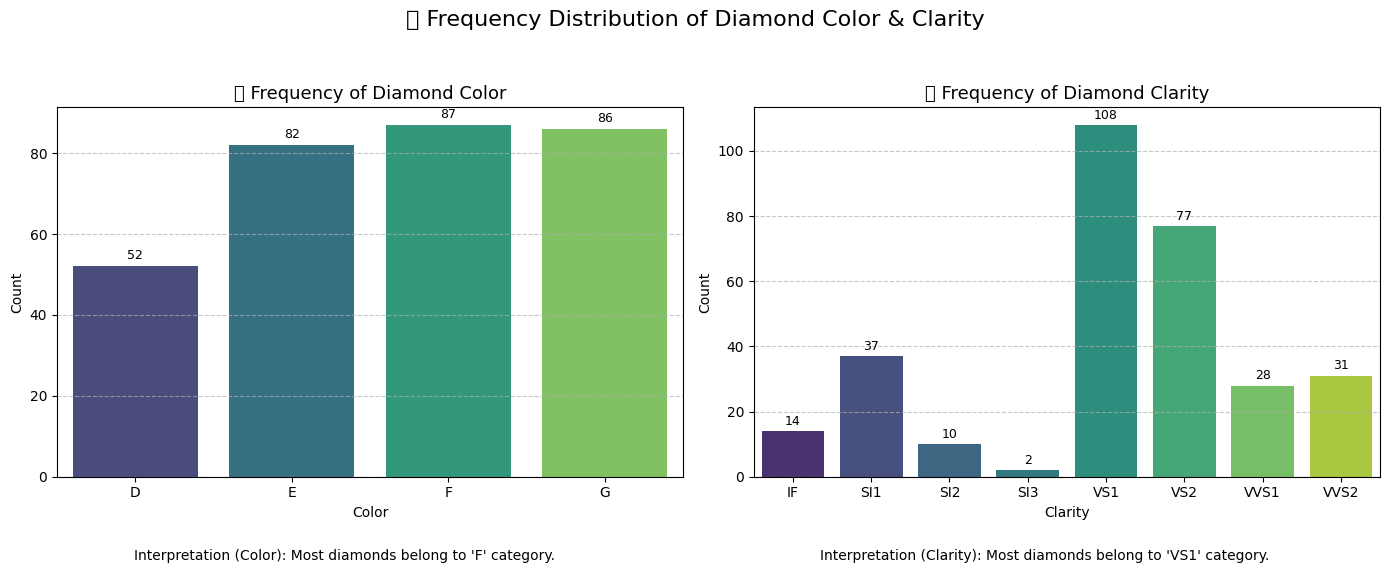

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Categorical columns in Diamond dataset
categorical_columns = ['Color', 'Clarity']

# Set figure size
plt.figure(figsize=(14, 5))

# Loop through categorical columns
for i, col in enumerate(categorical_columns, 1):
    plt.subplot(1, 2, i)

    # Count frequencies
    value_counts = df[col].value_counts().sort_index()

    # Bar plot
    sns.barplot(
        x=value_counts.index,
        y=value_counts.values,
        palette='viridis'
    )

    # Add count labels
    for j, val in enumerate(value_counts.values):
        plt.text(j, val + 1, str(val), ha='center', va='bottom', fontsize=9)

    # Titles and labels
    plt.title(f"📊 Frequency of Diamond {col}", fontsize=13)
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    # Mode interpretation
    mode_val = df[col].mode()[0]
    plt.figtext(
        0.25 if col == 'Color' else 0.75,
        -0.05,
        f"Interpretation ({col}): Most diamonds belong to '{mode_val}' category.",
        ha='center',
        fontsize=10
    )

plt.suptitle("💎 Frequency Distribution of Diamond Color & Clarity", fontsize=16, y=1.05)
plt.tight_layout()
plt.show()


BIVARIATE ANALYSIS

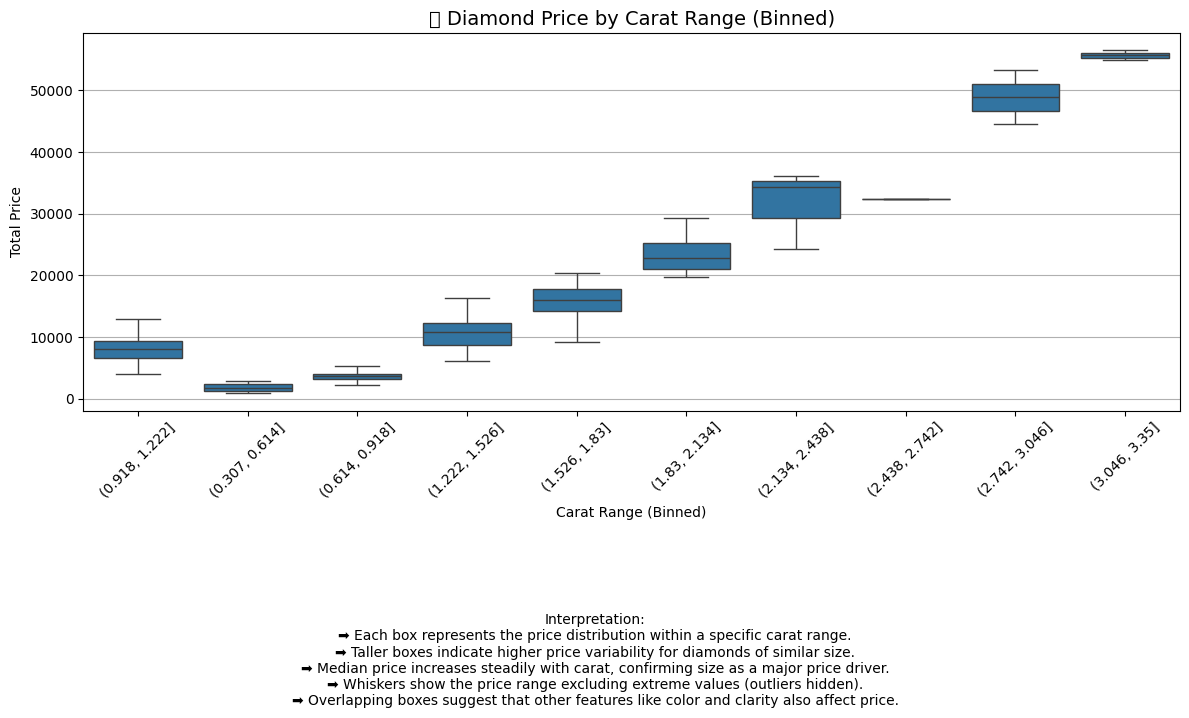

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ================================
# Bin Carat into 10 equal-width bins
# ================================
df['Carat_Bin'] = pd.cut(df['Carat'], bins=10).astype(str)

# ================================
# Create boxplot
# ================================
plt.figure(figsize=(12, 6))
sns.boxplot(
    x='Carat_Bin',
    y='TotalPrice',
    data=df,
    showfliers=False
)

# Rotate x-axis labels
plt.xticks(rotation=45)

# ================================
# Titles and labels
# ================================
plt.title("💰 Diamond Price by Carat Range (Binned)", fontsize=14)
plt.xlabel("Carat Range (Binned)")
plt.ylabel("Total Price")
plt.grid(axis='y')

# ================================
# Teaching-style interpretation
# ================================
plt.figtext(
    0.5, -0.18,
    "Interpretation:\n"
    "➡️ Each box represents the price distribution within a specific carat range.\n"
    "➡️ Taller boxes indicate higher price variability for diamonds of similar size.\n"
    "➡️ Median price increases steadily with carat, confirming size as a major price driver.\n"
    "➡️ Whiskers show the price range excluding extreme values (outliers hidden).\n"
    "➡️ Overlapping boxes suggest that other features like color and clarity also affect price.",
    wrap=True,
    ha='center',
    fontsize=10
)

# ================================
# Final display
# ================================
plt.tight_layout(rect=[0, 0.1, 1, 1])
plt.show()


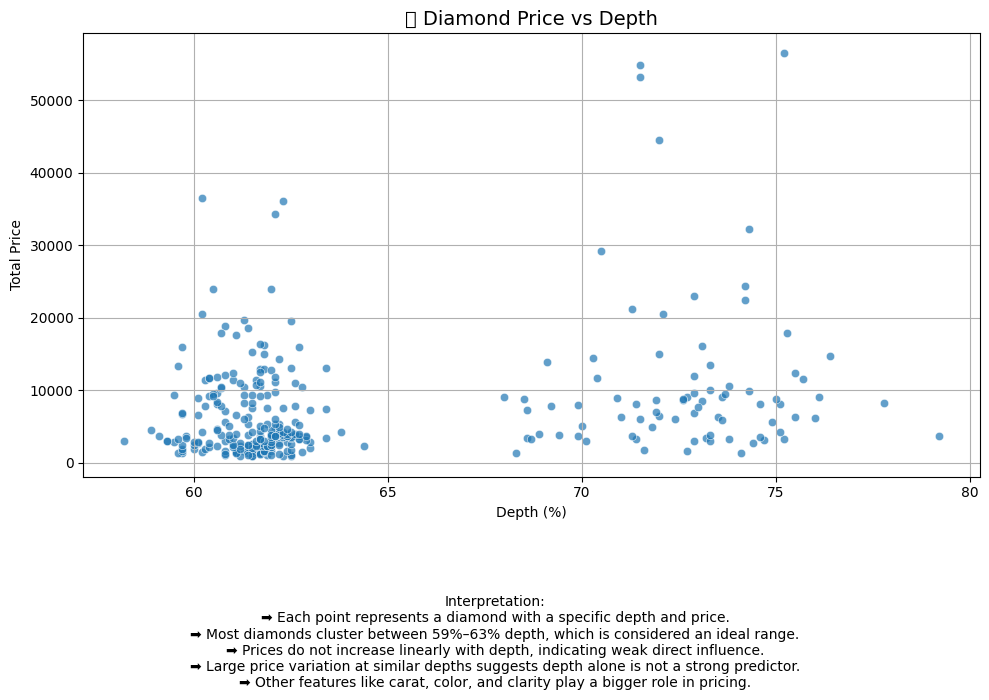

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ================================
# Scatter Plot: Depth vs Total Price
# ================================
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='Depth',
    y='TotalPrice',
    data=df,
    alpha=0.7
)

# Titles and labels
plt.title("💎 Diamond Price vs Depth", fontsize=14)
plt.xlabel("Depth (%)")
plt.ylabel("Total Price")
plt.grid(True)

# ================================
# Teaching-style interpretation
# ================================
plt.figtext(
    0.5, -0.15,
    "Interpretation:\n"
    "➡️ Each point represents a diamond with a specific depth and price.\n"
    "➡️ Most diamonds cluster between 59%–63% depth, which is considered an ideal range.\n"
    "➡️ Prices do not increase linearly with depth, indicating weak direct influence.\n"
    "➡️ Large price variation at similar depths suggests depth alone is not a strong predictor.\n"
    "➡️ Other features like carat, color, and clarity play a bigger role in pricing.",
    wrap=True,
    ha='center',
    fontsize=10
)

plt.tight_layout(rect=[0, 0.1, 1, 1])
plt.show()


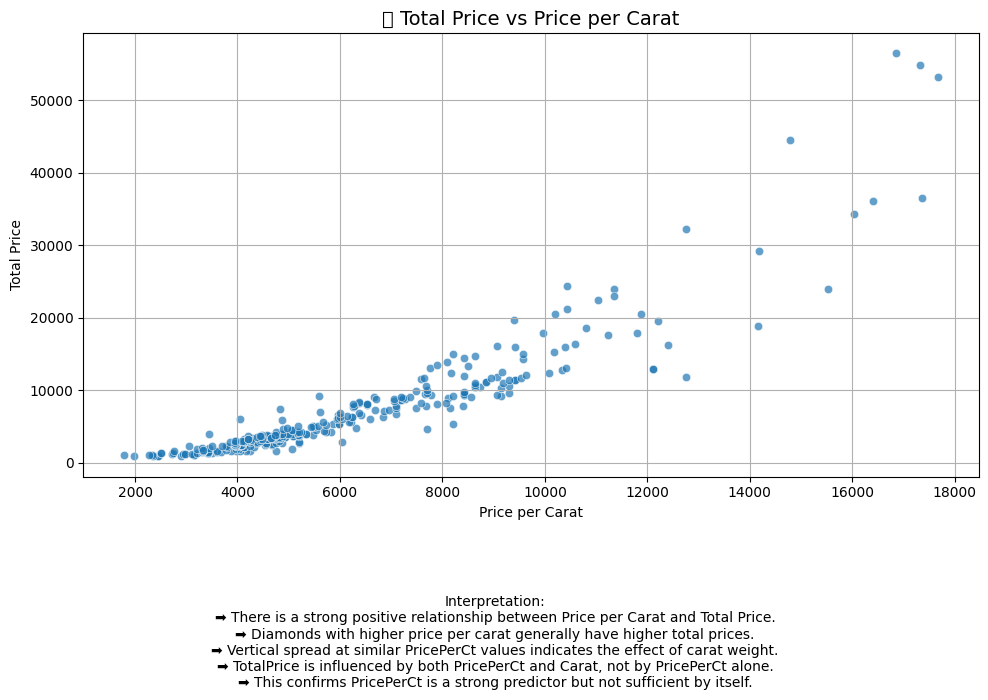

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='PricePerCt',
    y='TotalPrice',
    data=df,
    alpha=0.7
)

# Titles and labels
plt.title("💎 Total Price vs Price per Carat", fontsize=14)
plt.xlabel("Price per Carat")
plt.ylabel("Total Price")
plt.grid(True)

# Teaching-style interpretation
plt.figtext(
    0.5, -0.15,
    "Interpretation:\n"
    "➡️ There is a strong positive relationship between Price per Carat and Total Price.\n"
    "➡️ Diamonds with higher price per carat generally have higher total prices.\n"
    "➡️ Vertical spread at similar PricePerCt values indicates the effect of carat weight.\n"
    "➡️ TotalPrice is influenced by both PricePerCt and Carat, not by PricePerCt alone.\n"
    "➡️ This confirms PricePerCt is a strong predictor but not sufficient by itself.",
    wrap=True,
    ha='center',
    fontsize=10
)

plt.tight_layout(rect=[0, 0.1, 1, 1])
plt.show()


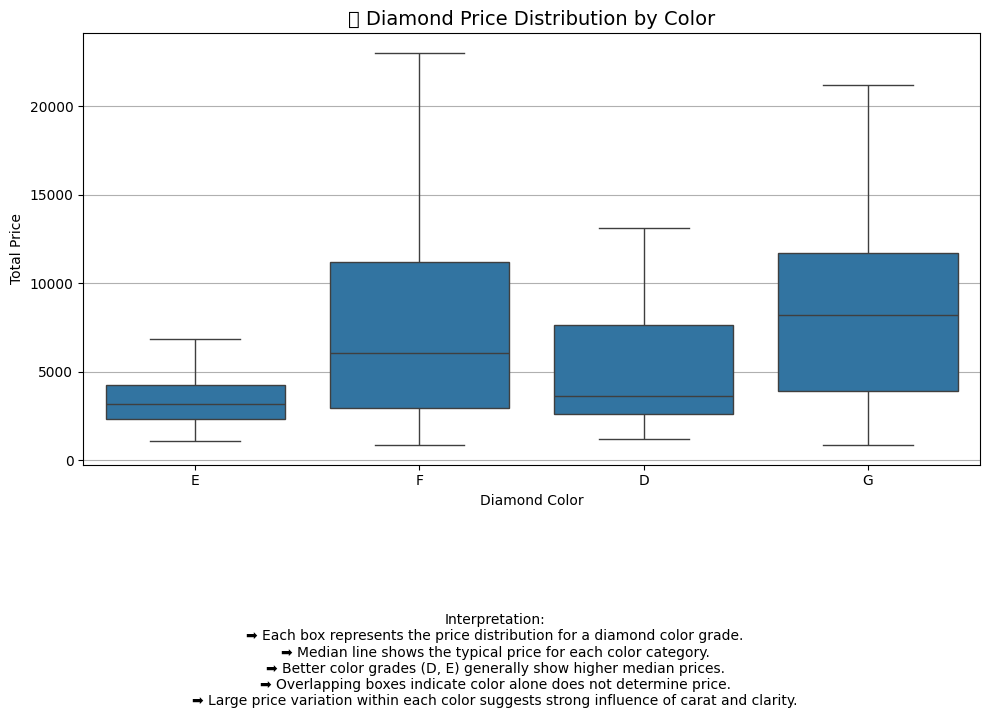

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.boxplot(
    x='Color',
    y='TotalPrice',
    data=df,
    showfliers=False
)

# Titles and labels
plt.title("💎 Diamond Price Distribution by Color", fontsize=14)
plt.xlabel("Diamond Color")
plt.ylabel("Total Price")
plt.grid(axis='y')

# Teaching-style interpretation
plt.figtext(
    0.5, -0.18,
    "Interpretation:\n"
    "➡️ Each box represents the price distribution for a diamond color grade.\n"
    "➡️ Median line shows the typical price for each color category.\n"
    "➡️ Better color grades (D, E) generally show higher median prices.\n"
    "➡️ Overlapping boxes indicate color alone does not determine price.\n"
    "➡️ Large price variation within each color suggests strong influence of carat and clarity.",
    wrap=True,
    ha='center',
    fontsize=10
)

plt.tight_layout(rect=[0, 0.12, 1, 1])
plt.show()


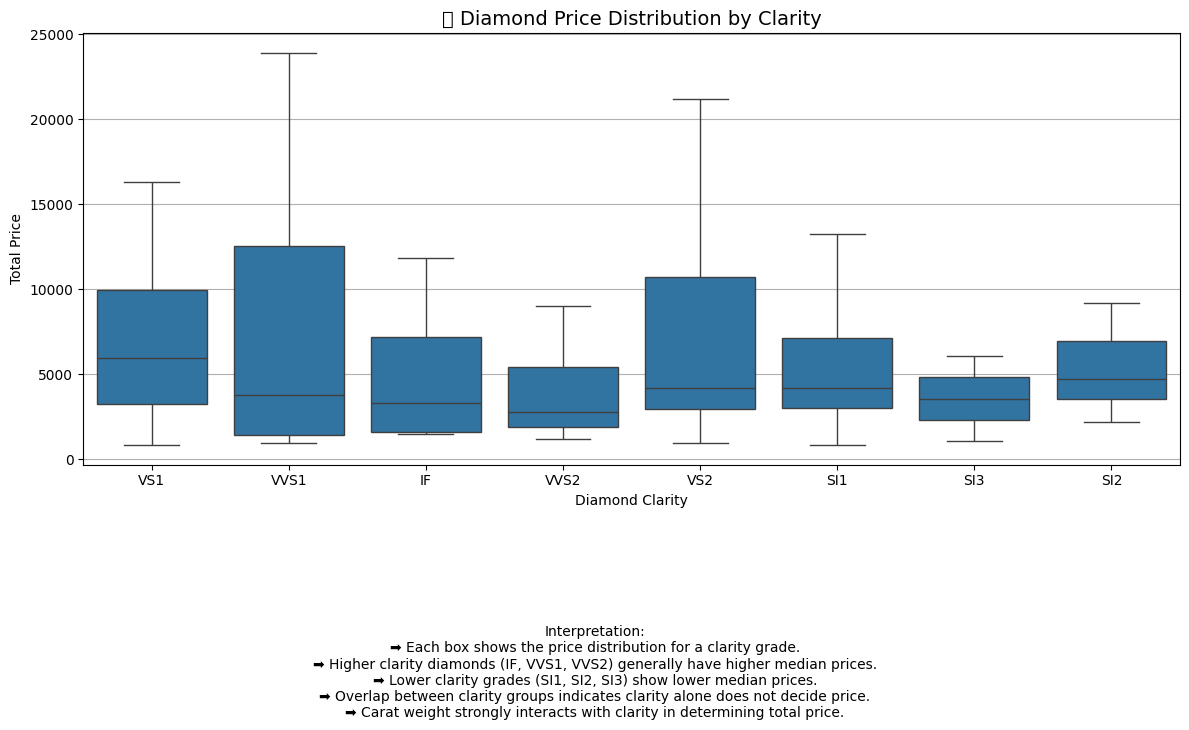

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))

sns.boxplot(
    x='Clarity',
    y='TotalPrice',
    data=df,
    showfliers=False
)

# Titles and labels
plt.title("💎 Diamond Price Distribution by Clarity", fontsize=14)
plt.xlabel("Diamond Clarity")
plt.ylabel("Total Price")
plt.grid(axis='y')

# Teaching-style interpretation
plt.figtext(
    0.5, -0.2,
    "Interpretation:\n"
    "➡️ Each box shows the price distribution for a clarity grade.\n"
    "➡️ Higher clarity diamonds (IF, VVS1, VVS2) generally have higher median prices.\n"
    "➡️ Lower clarity grades (SI1, SI2, SI3) show lower median prices.\n"
    "➡️ Overlap between clarity groups indicates clarity alone does not decide price.\n"
    "➡️ Carat weight strongly interacts with clarity in determining total price.",
    wrap=True,
    ha='center',
    fontsize=10
)

plt.tight_layout(rect=[0, 0.12, 1, 1])
plt.show()


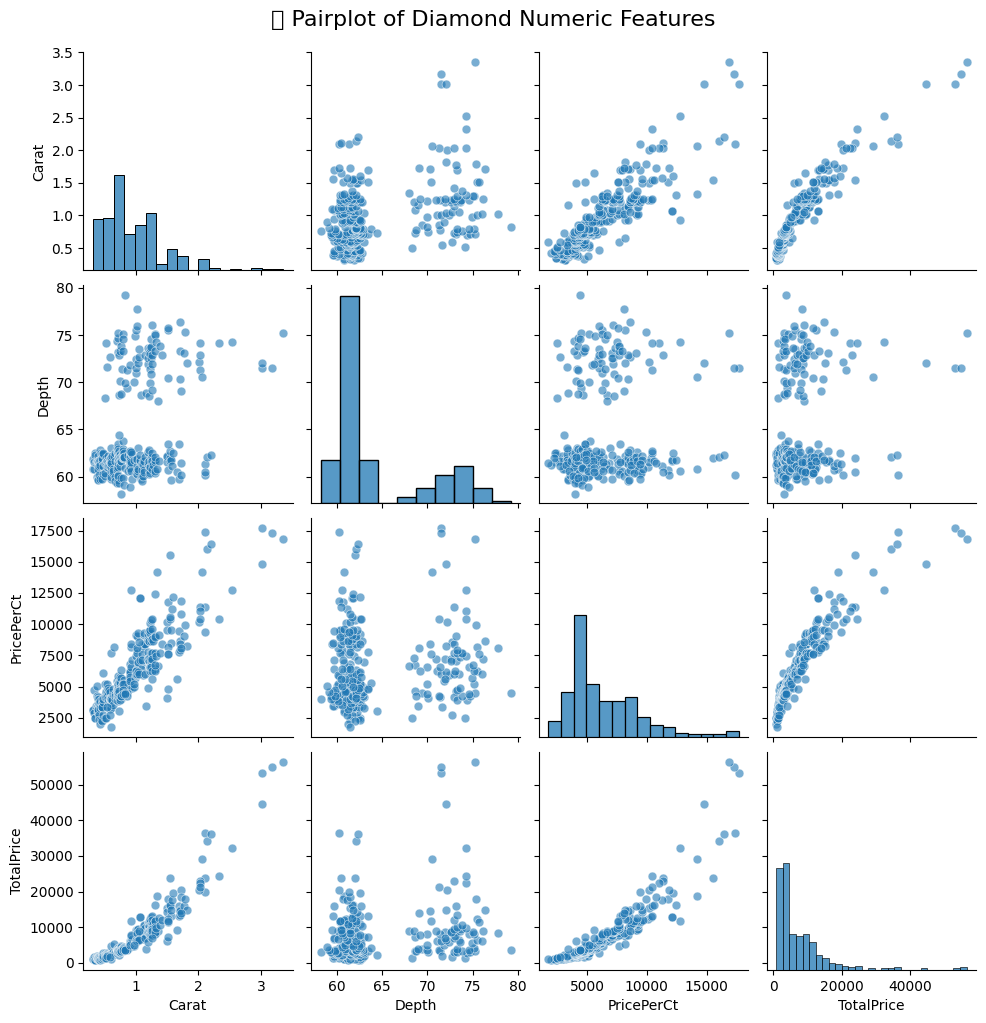

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select numeric columns for diamond dataset
num_cols = ['Carat', 'Depth', 'PricePerCt', 'TotalPrice']

# Create pairplot
sns.pairplot(
    df[num_cols],
    diag_kind='hist',
    plot_kws={'alpha': 0.6, 's': 40}
)

# Overall title
plt.suptitle("🔍 Pairplot of Diamond Numeric Features", fontsize=16, y=1.02)
plt.show()


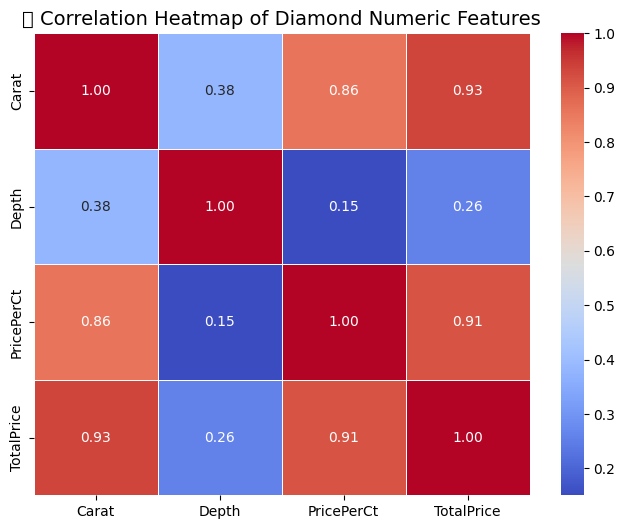

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select numeric columns only
numeric_cols = ['Carat', 'Depth', 'PricePerCt', 'TotalPrice']

# Compute correlation matrix
corr_matrix = df[numeric_cols].corr()

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    linewidths=0.5
)

# Titles
plt.title("🔥 Correlation Heatmap of Diamond Numeric Features", fontsize=14)
plt.show()


In [ ]:
# Print data types of each column in the DataFrame
print(df.dtypes)


Carat         float64
Color          object
Clarity        object
Depth         float64
PricePerCt    float64
TotalPrice    float64
Carat_Bin      object
dtype: object


In [ ]:
import numpy as np
import pandas as pd

# ================================
# Z-score based outlier detection function
# ================================
def detect_outliers_zscore(series, threshold=3):
    mean = series.mean()
    std = series.std()

    z_scores = (series - mean) / std
    outliers = series[np.abs(z_scores) > threshold]

    return outliers


# ================================
# Apply Z-score method to numeric columns
# ================================
numeric_cols = ['Carat', 'Depth', 'PricePerCt', 'TotalPrice']

outlier_summary = {}

for col in numeric_cols:
    outliers = detect_outliers_zscore(df[col])
    outlier_summary[col] = len(outliers)

    print(f"\n🔹 Column: {col}")
    print(f"Number of outliers detected (Z-score): {len(outliers)}")
    print(outliers.head())  # show first few outliers



🔹 Column: Carat
Number of outliers detected (Z-score): 5
297    2.53
298    3.01
299    3.01
300    3.17
301    3.35
Name: Carat, dtype: float64

🔹 Column: Depth
Number of outliers detected (Z-score): 0
Series([], Name: Depth, dtype: float64)

🔹 Column: PricePerCt
Number of outliers detected (Z-score): 7
206    15525.0
217    17367.8
220    16023.2
221    16409.3
298    17671.5
Name: PricePerCt, dtype: float64

🔹 Column: TotalPrice
Number of outliers detected (Z-score): 8
217    36472.3
220    34289.5
221    36100.4
297    32276.5
298    53191.2
Name: TotalPrice, dtype: float64


In [ ]:
# =========================================
# 1️⃣ Imports
# =========================================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# =========================================
# 2️⃣ Load Dataset (CSV or Excel)
# =========================================
# Use the file that EXISTS in your directory
df = pd.read_csv("Diamond_Price.csv")   # change ONLY if needed

print("Initial shape:", df.shape)
print("\nSample rows:")
print(df.head())


# =========================================
# 3️⃣ One-Hot Encoding (MANDATORY)
# =========================================
# Encode ALL categorical columns
df_encoded = pd.get_dummies(
    df,
    columns=['Color', 'Clarity'],
    drop_first=True
)

print("\nAfter encoding shape:", df_encoded.shape)


# =========================================
# 4️⃣ Split Features & Target
# =========================================
X = df_encoded.drop(columns=['TotalPrice'])
y = df_encoded['TotalPrice']

print("\nX shape:", X.shape)
print("y shape:", y.shape)


# =========================================
# 5️⃣ Train-Test Split
# =========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("\nTrain shape:", X_train.shape)
print("Test shape:", X_test.shape)


# =========================================
# 6️⃣ Random Forest Model Training
# =========================================
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)


# =========================================
# 7️⃣ Prediction
# =========================================
y_pred = rf_model.predict(X_test)


# =========================================
# 8️⃣ Evaluation (Regression Metrics)
# =========================================
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\n📊 Model Performance:")
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")


Initial shape: (307, 8)

Sample rows:
   Unnamed: 0  X  Carat Color Clarity  Depth  PricePerCt  TotalPrice
0           1  1   1.08     E     VS1   68.6      6693.3      7228.8
1           2  2   0.31     F    VVS1   61.9      3159.0       979.3
2           3  3   0.32     F    VVS1   60.8      3159.0      1010.9
3           4  4   0.33     D      IF   60.8      4758.8      1570.4
4           5  5   0.33     G    VVS1   61.5      2895.8       955.6

After encoding shape: (307, 16)

X shape: (307, 15)
y shape: (307,)

Train shape: (245, 15)
Test shape: (62, 15)

📊 Model Performance:
MAE  : 265.54
RMSE : 514.28
R²   : 0.9942


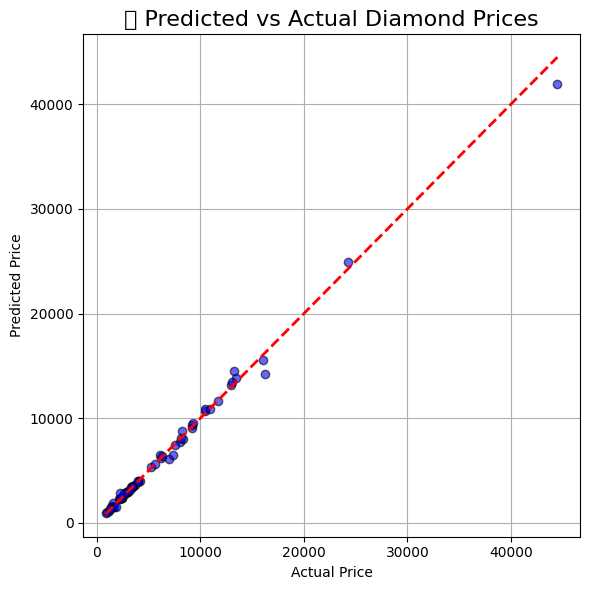

In [ ]:
#PREDICTED vs ACTUAL
import matplotlib.pyplot as plt

# =========================================
# Plot Predicted vs Actual Diamond Prices
# =========================================

# Why?
# - Visual comparison helps evaluate regression performance.
# - Points close to the diagonal line (y = x) indicate accurate predictions.
# - Points far from the line represent prediction errors.
# - Complements numerical metrics like RMSE and R².

plt.figure(figsize=(6, 6))
plt.scatter(
    y_test,
    y_pred,
    alpha=0.6,
    color='blue',
    edgecolor='k'
)

# Diagonal line representing perfect predictions
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    lw=2
)

plt.title("📊 Predicted vs Actual Diamond Prices", fontsize=16)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.grid(True)
plt.tight_layout()
plt.show()


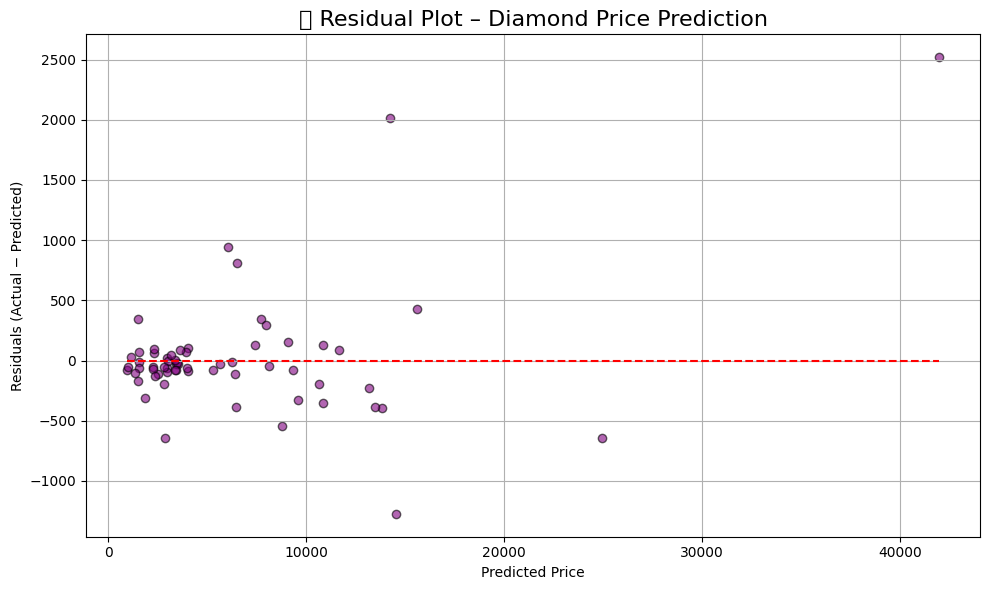

In [ ]:
#RESIDUAL PLOT — DIAMOND PRICE REGRESSION
import matplotlib.pyplot as plt
import numpy as np

# =========================================
# Calculate residuals (errors)
# Residual = Actual Price − Predicted Price
# =========================================
residuals = y_test - y_pred


# =========================================
# Residual Plot: Predicted Price vs Residuals
# =========================================
plt.figure(figsize=(10, 6))
plt.scatter(
    y_pred,
    residuals,
    alpha=0.6,
    edgecolor='k',
    color='purple'
)

# Horizontal line at zero (ideal residual)
plt.hlines(
    y=0,
    xmin=y_pred.min(),
    xmax=y_pred.max(),
    colors='red',
    linestyles='dashed'
)

plt.title("📉 Residual Plot – Diamond Price Prediction", fontsize=16)
plt.xlabel("Predicted Price")
plt.ylabel("Residuals (Actual − Predicted)")
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
#TRAIN vs TEST R² — RANDOM FOREST (DIAMOND DATASET)
from sklearn.metrics import r2_score

# =========================================
# Evaluate model on TRAINING data
# =========================================
y_train_pred = rf_model.predict(X_train)
train_r2 = r2_score(y_train, y_train_pred)

# =========================================
# Evaluate model on TEST data
# =========================================
y_test_pred = rf_model.predict(X_test)
test_r2 = r2_score(y_test, y_test_pred)

print(f"Train R² Score : {train_r2:.4f}")
print(f"Test  R² Score : {test_r2:.4f}")


Train R² Score : 0.9971
Test  R² Score : 0.9942


In [ ]:
# =========================================================
# STEP 1–6: Random Forest Hyperparameter Tuning (ALL-IN-ONE)
# =========================================================

import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import r2_score

# ---------------------------------------------------------
# STEP 1: Define hyperparameter search space
# ---------------------------------------------------------
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 5, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

# ---------------------------------------------------------
# STEP 2: Initialize base Random Forest model
# ---------------------------------------------------------
rf = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

# ---------------------------------------------------------
# STEP 3: Setup RandomizedSearchCV
# ---------------------------------------------------------
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=30,            # Number of random combinations
    scoring='r2',         # Regression metric
    cv=5,                 # 5-fold cross-validation
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# ---------------------------------------------------------
# STEP 4: Fit RandomizedSearchCV on training data
# ---------------------------------------------------------
random_search.fit(X_train, y_train)

# ---------------------------------------------------------
# STEP 5: Extract best model and best parameters
# ---------------------------------------------------------
best_rf_model = random_search.best_estimator_

print("\n✅ Best Hyperparameters:")
print(random_search.best_params_)

# ---------------------------------------------------------
# STEP 6: Evaluate tuned model (Train vs Test)
# ---------------------------------------------------------
y_train_pred = best_rf_model.predict(X_train)
y_test_pred = best_rf_model.predict(X_test)

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("\n📊 Tuned Model Performance:")
print(f"Train R² Score : {train_r2:.4f}")
print(f"Test  R² Score : {test_r2:.4f}")


Fitting 5 folds for each of 30 candidates, totalling 150 fits

✅ Best Hyperparameters:
{'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': None}

📊 Tuned Model Performance:
Train R² Score : 0.9977
Test  R² Score : 0.9944


In [ ]:
# After RandomizedSearchCV
best_rf = random_search.best_estimator_

# Save the tuned model
import joblib
joblib.dump(best_rf, "diamond_price_random_forest_model.pkl")
print("💾 Tuned model saved successfully")


💾 Tuned model saved successfully


In [ ]:
#Feature Importance Ranking
import pandas as pd

# Use the trained model (best_rf if tuned, else rf_model)
model_to_use = best_rf if 'best_rf' in globals() else rf_model

# Create feature importance DataFrame
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': model_to_use.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Display ranking
feature_importance


,Feature,Importance
2,Carat,0.519044
4,PricePerCt,0.429853
1,X,0.017672
0,Unnamed: 0,0.017661
14,Clarity_VVS2,0.004644
3,Depth,0.004010
11,Clarity_VS1,0.003060
6,Color_F,0.001481
7,Color_G,0.001037
13,Clarity_VVS1,0.000668


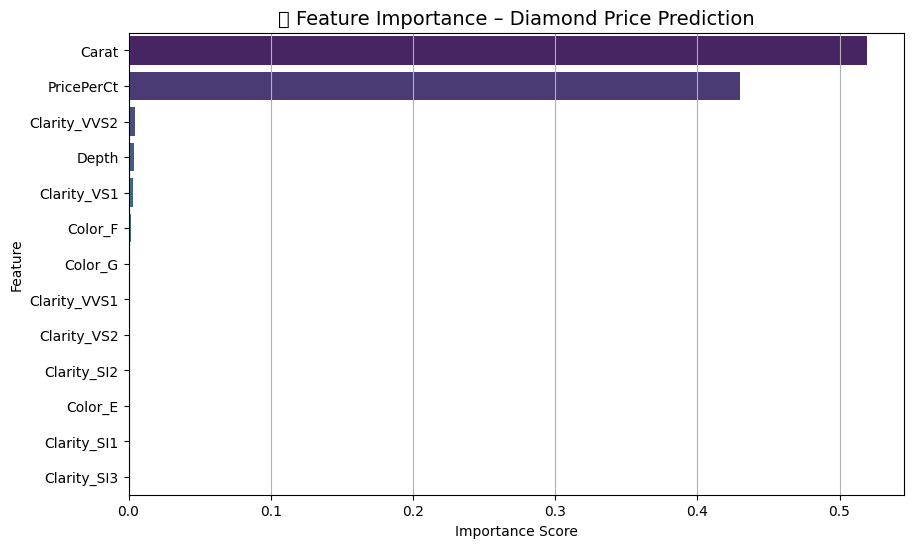

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Remove unwanted features
feature_importance_cleaned = feature_importance[
    ~feature_importance['Feature'].isin(['Unnamed: 0', 'X'])
]

# Plot feature importance
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance_cleaned,
    palette='viridis'
)

plt.title("🌟 Feature Importance – Diamond Price Prediction", fontsize=14)
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.grid(axis='x')
plt.show()
